In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import windows
#from statsmodels.nonparametric.smoothers_lowess import lowess

In [2]:
path = '/Users/noavisser/Documents/event_annotation/narrativity_arcs/metamorphosis/'
out = '/Users/noavisser/Documents/event_annotation/narrativity_arcs/meta_res/'
bi = pd.read_csv(f'{path}/CURATION_USER_BI.csv') 
dutch = pd.read_csv(f'{path}/CURATION_USER_Dutch.csv')
korean = pd.read_csv(f'{path}/CURATION_USER_Korean.csv')
italian = pd.read_csv(f'{path}/CURATION_USER_Italian.csv')
german = pd.read_csv(f'{path}/CURATION_USER_German.csv')

dfs = { 'german': german, 'bi': bi, 'dutch': dutch, 'italian': italian}

In [3]:
label_map = {
    'non_event': 0,
    'stative_event': 2,
    'process': 5,
    'change_of_state': 7,
}

In [4]:
def label_num(df):
    suffix_1 = df['event_bio'].str.split('-', n=1).str[-1]
    suffix_2 = df['event_bio_2'].str.split('-', n=1).str[-1]

    mapped_1 = suffix_1.map(label_map)
    mapped_2 = suffix_2.map(label_map)

    df['label_num'] = pd.concat([mapped_1, mapped_2], axis=1).max(axis=1, skipna=True)
    return df

In [5]:
for df in [german, bi, dutch, italian]:
    label_num(df)

In [6]:
def plot_all_cosine(dfs, language_map, window_frac=0.05, window_size=None, figsize=(12, 6)):
    """
    Plot cosine-weighted smoothed event curves for multiple translations on ONE shared graph,
    aligned by percentage of text (0-100%) so texts of different lengths are comparable.

    window_frac: smoothing window as a fraction of each text's own length (default 5%).
                 This keeps smoothing 'grain' comparable across texts of different lengths.
    window_size: if set, overrides window_frac with a FIXED number of rows for every text
                 (use only if you want identical absolute windows).
    """
    # Okabe-Ito palette — chosen so hues stay distinguishable under deuteranopia/protanopia,
    # not just under normal vision. Swapped out red/orange/yellow, which collapse together
    # for red-green color blindness.
    colorblind_colors = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7']
    linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]  # backup cue beyond color alone

    plt.figure(figsize=figsize)

    for (key, df), color, ls in zip(dfs.items(), colorblind_colors, linestyles):
        df = df.dropna(subset=['label_num']).reset_index(drop=True)
        df["Percent"] = df.index / (len(df) - 1) * 100

        if window_size is not None:
            w = window_size
        else:
            w = max(5, int(len(df) * window_frac))
            if w % 2 == 0:
                w += 1  # odd window centers cleanly

        cosine_kernel = windows.cosine(w)
        normalized_weights = cosine_kernel / np.sum(cosine_kernel)

        df["Cosine_Smoothed"] = (
            df['label_num']
            .rolling(window=w, center=True, min_periods=1)
            .apply(
                lambda x: np.sum(x * normalized_weights[: len(x)])
                / np.sum(normalized_weights[: len(x)]),
                raw=True,
            )
        )

        plt.plot(df["Percent"], df["Cosine_Smoothed"], label=language_map.get(key, key),
                  linewidth=2, color=color, linestyle=ls)

    plt.title("Cosine-Weighted Event Curve — Metamorphosis (all translations)")
    plt.xlabel("Position in text excerpt (%)")
    plt.ylabel("Event type (weighted)")
    plt.ylim(0, 7)
    plt.yticks(range(8))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{out}/metamorphosis_combined_cosine.pdf', dpi=150)
    plt.show()

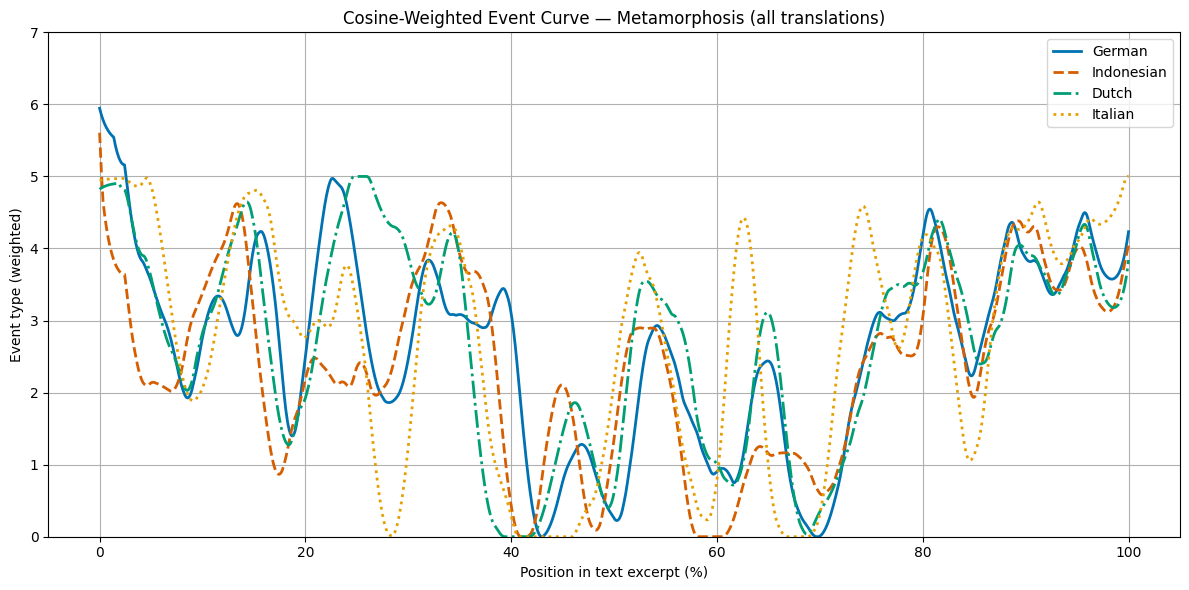

In [7]:
plot_all_cosine(
    dfs,
    language_map={'german':'German', 'bi': 'Indonesian', 'dutch': 'Dutch', 'italian': 'Italian'},
    window_frac=0.05,  # try adjusting this: smaller = more detail, larger = smoother
)
